In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.ticker as mtick

plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

df = pd.read_csv("/content/sample_data/corona_lab_tests_2020.csv")
df.head()


,result_date,corona_result,lab_id,test_for_corona_diagnosis,is_first_Test
0,2020-03-11,חיובי,32,1,Yes
1,2020-03-11,חיובי,32,0,No
2,2020-03-11,חיובי,32,0,No
3,2020-03-11,חיובי,32,0,No
4,2020-03-11,שלילי,2,1,Yes


In [63]:
df['corona_result'] = df['corona_result'].str.strip()

valid_results = ['חיובי', 'חיובי גבולי', 'שלילי']
df = df[df['corona_result'].isin(valid_results)].copy()

df['positive'] = df['corona_result'].isin(['חיובי', 'חיובי גבולי']).astype(int)

df['result_date'] = pd.to_datetime(df['result_date'])

df['month'] = df['result_date'].dt.to_period('M')
df['week'] = df['result_date'].dt.isocalendar().week

print("After cleaning shape:", df.shape)
print(df['corona_result'].value_counts())



After cleaning shape: (8049408, 8)
corona_result
שלילי          7489372
חיובי           491161
חיובי גבולי      68875
Name: count, dtype: int64


In [64]:
daily = df.groupby('result_date').agg(
    total_tests=('positive', 'count'),
    positive_cases=('positive', 'sum')
).reset_index()

daily['positivity_rate'] = daily['positive_cases'] / daily['total_tests']

daily['positive_7d_avg'] = daily['positive_cases'].rolling(7, min_periods=1).mean()
daily['rate_7d_avg'] = daily['positivity_rate'].rolling(7, min_periods=1).mean()

daily.head()


,result_date,total_tests,positive_cases,positivity_rate,positive_7d_avg,rate_7d_avg
0,2020-03-11,398,43,0.108040,43.000000,0.108040
1,2020-03-12,602,32,0.053156,37.500000,0.080598
2,2020-03-13,693,40,0.057720,38.333333,0.072972
3,2020-03-14,613,35,0.057096,37.500000,0.069003
4,2020-03-15,1078,91,0.084416,48.200000,0.072086


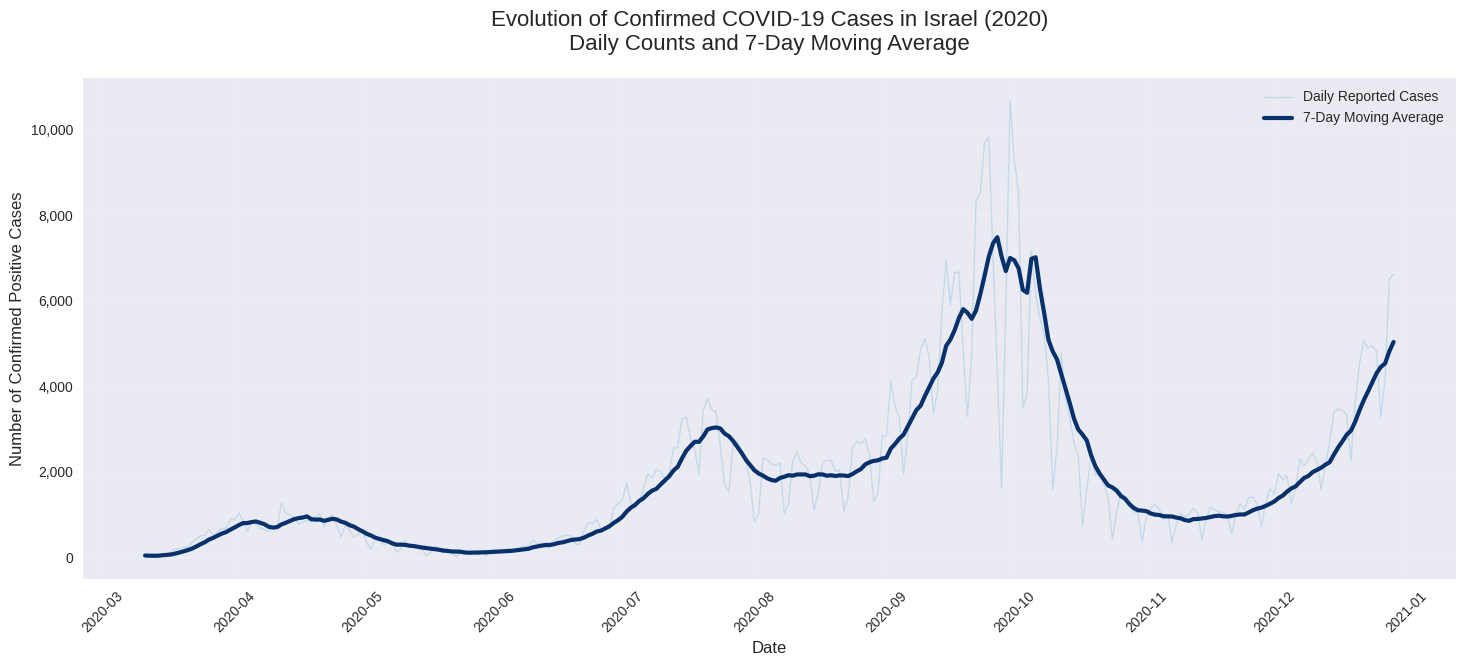

In [65]:

plt.figure(figsize=(15,7))

plt.plot(
    daily['result_date'],
    daily['positive_cases'],
    color='#9ecae1',
    alpha=0.5,
    linewidth=1,
    label='Daily Reported Cases'
)


plt.plot(
    daily['result_date'],
    daily['positive_7d_avg'],
    color='#08306b',
    linewidth=3,
    label='7-Day Moving Average'
)

plt.title(
    "Evolution of Confirmed COVID-19 Cases in Israel (2020)\n"
    "Daily Counts and 7-Day Moving Average",
    fontsize=16,
    pad=20
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Confirmed Positive Cases", fontsize=12)


plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: format(int(x), ','))
)


plt.grid(alpha=0.2)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


plt.legend(frameon=False)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


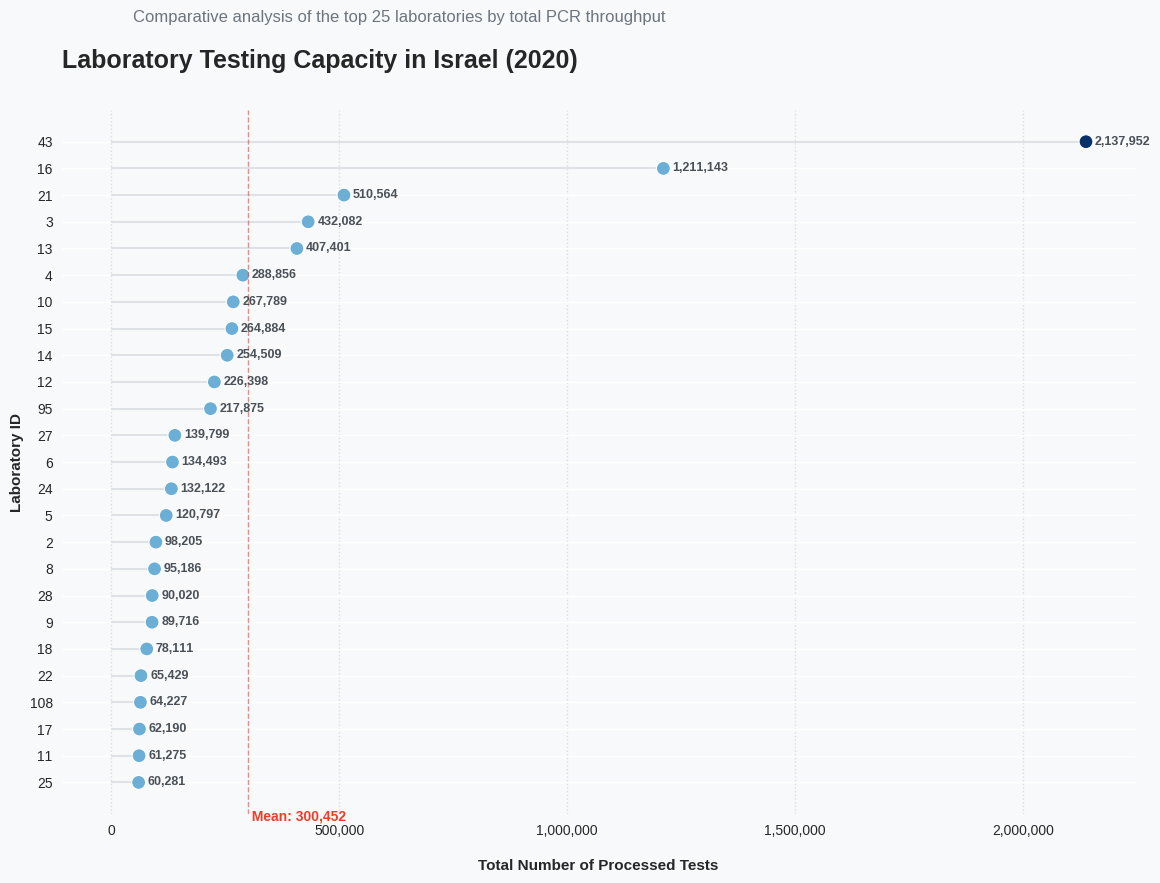

In [66]:

top_n = 25
lab_counts = df.groupby('lab_id').size().reset_index(name='tests')
lab_counts = lab_counts.sort_values('tests', ascending=True).tail(top_n)

fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
background_color = "#f8f9fa"
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)


ax.hlines(y=lab_counts['lab_id'].astype(str), xmin=0, xmax=lab_counts['tests'],
          color='#dee2e6', linewidth=1.5, zorder=1)

colors = ['#08306b' if x == lab_counts['tests'].max() else '#6baed6' for x in lab_counts['tests']]
ax.scatter(lab_counts['tests'], lab_counts['lab_id'].astype(str),
           color=colors, s=100, edgecolors='white', linewidth=0.8, zorder=2)

for i, v in enumerate(lab_counts['tests']):
    ax.text(v + 20000, i, f"{v:,.0f}", color='#495057', va='center', fontweight='bold', fontsize=9)


mean_val = lab_counts['tests'].mean()
ax.axvline(mean_val, color='#ef3b2c', linestyle='--', alpha=0.6, linewidth=1)
ax.text(mean_val, -1, f' Mean: {mean_val:,.0f}', color='#ef3b2c', ha='left', va='top', fontsize=10, fontweight='bold')

plt.title("Laboratory Testing Capacity in Israel (2020)", loc='left', fontsize=18, fontweight='bold', pad=30)
plt.suptitle("Comparative analysis of the top 25 laboratories by total PCR throughput",
             x=0.125, y=0.92, ha='left', fontsize=12, color='#6c757d')

plt.xlabel("Total Number of Processed Tests", fontsize=11, fontweight='bold', labelpad=15)
plt.ylabel("Laboratory ID", fontsize=11, fontweight='bold')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#adb5bd')
ax.spines['left'].set_color('#adb5bd')

plt.grid(axis='x', linestyle=':', alpha=0.4, color='#adb5bd')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


In [67]:

lab_stats = df.groupby('lab_id').agg(
    positivity_rate=('positive', 'mean'),
    total_tests=('positive', 'count')
).reset_index()


min_tests_threshold = 500
filtered_labs = lab_stats[lab_stats['total_tests'] > min_tests_threshold].copy()
filtered_labs = filtered_labs.sort_values('positivity_rate', ascending=False)

national_avg = df['positive'].mean()

fig = px.bar(
    filtered_labs,
    x='lab_id',
    y='positivity_rate',
    color='positivity_rate',
    color_continuous_scale='Reds',
    title="<b>Analysis of COVID-19 Positivity Rate by Laboratory</b><br>" +
          "<sup>Labs with >500 tests shown. Redder bars indicate rates above the statistical norm.</sup>",
    labels={
        'lab_id': 'Laboratory Identifier',
        'positivity_rate': 'Positivity Rate',
        'total_tests': 'Total Volume'
    },
    hover_data={'total_tests': ':,', 'positivity_rate': ':.2%'},
    template='plotly_white'
)

fig.add_hline(
    y=national_avg,
    line_dash="dot",
    line_color="#333",
    annotation_text=f"National Average: {national_avg:.1%}",
    annotation_position="top right",
    annotation_font_color="#333"
)

fig.update_layout(
    yaxis_tickformat='.1%',
    xaxis_type='category',
    xaxis_tickangle=45,
    height=600,
    coloraxis_showscale=False,
    margin=dict(t=100, b=100, l=50, r=50),
    font=dict(family="Arial", size=12)
)


fig.show()



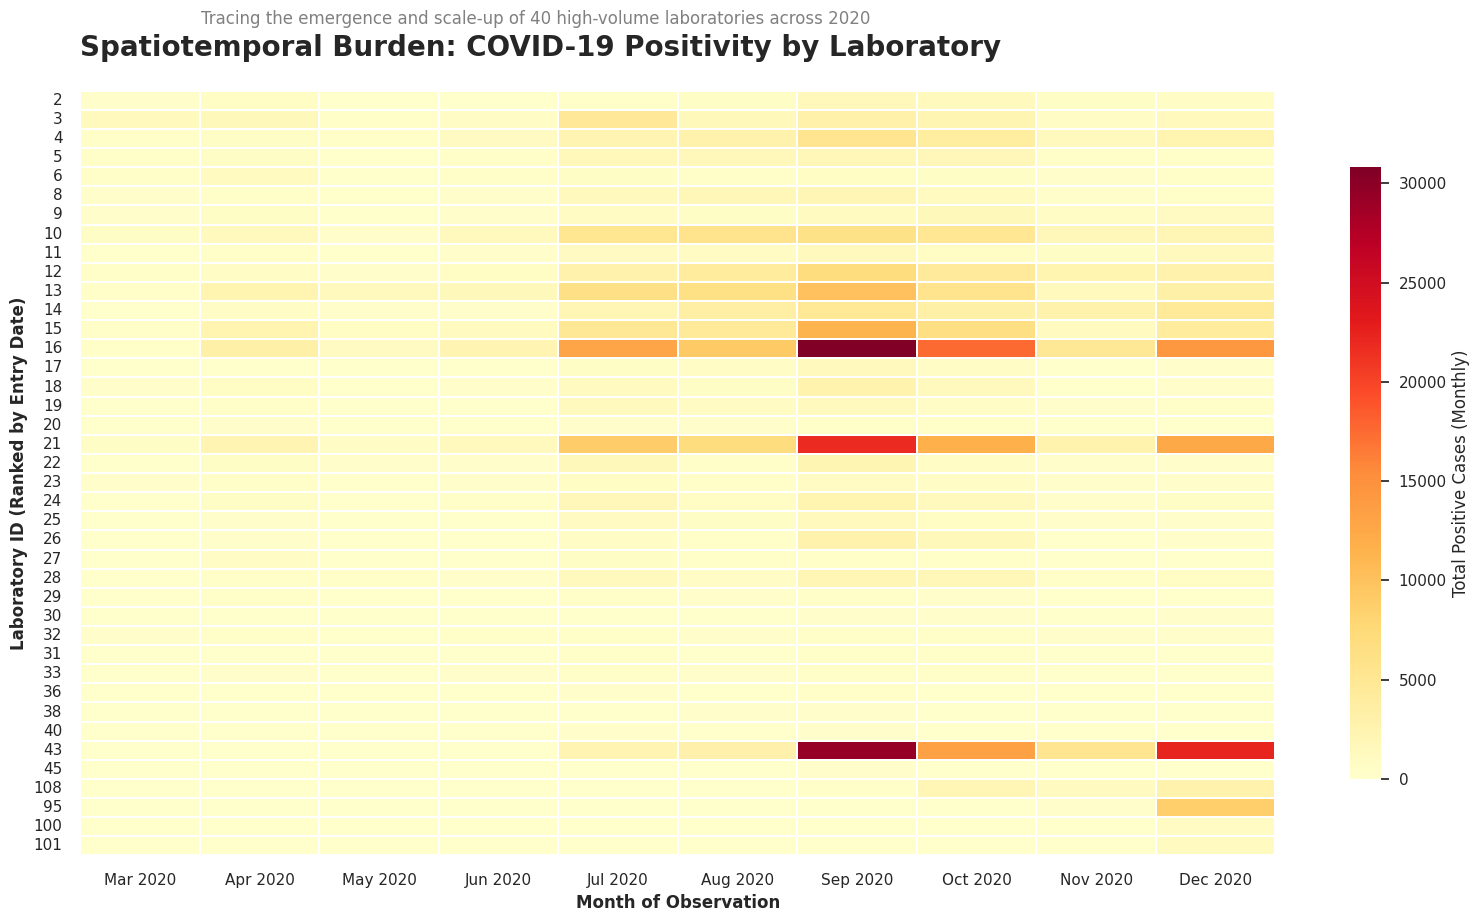

In [68]:
top_labs = df.groupby('lab_id')['positive'].sum().nlargest(40).index
df_filtered = df[df['lab_id'].isin(top_labs)].copy()


pivot_table = df_filtered.pivot_table(
    values='positive',
    index='lab_id',
    columns='month',
    aggfunc='sum'
).fillna(0)

first_appearance = (pivot_table > 0).idxmax(axis=1)
pivot_table = pivot_table.loc[first_appearance.sort_values().index]

plt.figure(figsize=(16, 10), dpi=100)
sns.set_theme(style="white")

from matplotlib.colors import LogNorm

ax = sns.heatmap(
    pivot_table,
    cmap="YlOrRd",
    linewidths=0.1,
    linecolor='white',
    cbar_kws={'label': 'Total Positive Cases (Monthly)', 'shrink': 0.8},
    annot=False
)

plt.title("Spatiotemporal Burden: COVID-19 Positivity by Laboratory",
          fontsize=20, fontweight='bold', pad=25, loc='left')
plt.suptitle("Tracing the emergence and scale-up of 40 high-volume laboratories across 2020",
             fontsize=12, x=0.34, y=0.92, color='gray')

plt.xlabel("Month of Observation", fontsize=12, fontweight='bold')
plt.ylabel("Laboratory ID (Ranked by Entry Date)", fontsize=12, fontweight='bold')

ax.set_xticklabels([pd.to_datetime(str(m)).strftime('%b %Y') for m in pivot_table.columns], rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



In [69]:
daily_diagnosis = df.groupby(['result_date', 'test_for_corona_diagnosis']).size().reset_index(name='count')

fig = px.line(
    daily_diagnosis,
    x='result_date',
    y='count',
    color='test_for_corona_diagnosis',
    title="Daily Tests by Diagnosis Type",
    labels={'count': 'Number of Tests'}
)

fig.show()


/tmp/ipython-input-1453586076.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




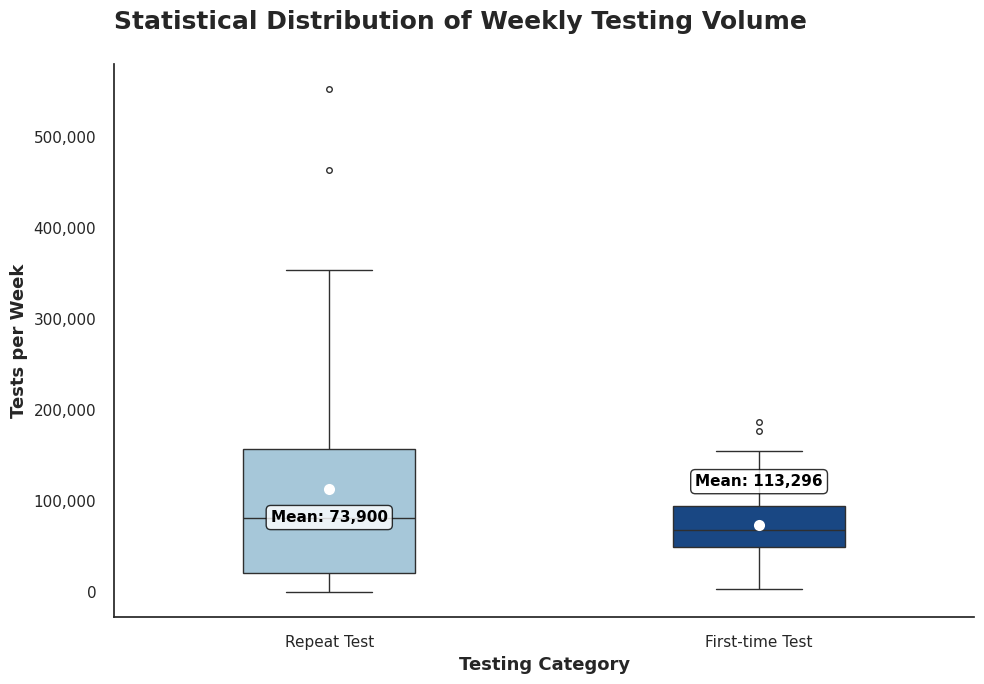

In [70]:

weekly_first = df.groupby(['week', 'is_first_Test']).size().reset_index(name='count')

label_map = {
    '0': 'Repeat Test', '1': 'First-time Test',
    '0.0': 'Repeat Test', '1.0': 'First-time Test',
    'No': 'Repeat Test', 'Yes': 'First-time Test'
}
weekly_first['Test_Type'] = weekly_first['is_first_Test'].astype(str).map(label_map)

sns.set_style("white")
plt.figure(figsize=(10, 7), dpi=100)
palette = {'First-time Test': "#084594", 'Repeat Test': "#9ecae1"}


sns.boxplot(
    data=weekly_first,
    x='Test_Type',
    y='count',
    palette=palette,
    width=0.4,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
    fliersize=4
)

means = weekly_first.groupby('Test_Type')['count'].mean()
for i, mean in enumerate(means):
    plt.text(i, mean, f'Mean: {mean:,.0f}',
             ha='center', va='bottom', fontsize=11,
             color='black', weight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'))

plt.title("Statistical Distribution of Weekly Testing Volume", fontsize=18, weight='bold', pad=25, loc='left')
plt.xlabel("Testing Category", fontsize=13, weight='semibold')
plt.ylabel("Tests per Week", fontsize=13, weight='semibold')

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.despine()
plt.tight_layout()
plt.show()